# Interventions on the compliance-vs-reasoning-length plane (held-out modes)

One panel per model. Every line: strict compliance vs reasoning length (log-spaced word bins), on the
**3 held-out constraint modes** (start_of_sentence / letter_suppression / no_spaces) — the only setting where
all five intervention families were evaluated.

| family | source | split | n/line |
|---|---|---|---|
| baseline | `baselines/{m}_heldout/` | test | 1500 |
| GEPA (top-3 of 6 variants by held-out strict; best bold) | `gepa/runs/*/heldout_eval/` | test | 1500 |
| few-shot k=1 (3 demo seeds; best bold) | `fewshot/runs/final_k1_heldout/` | test | 1500 |
| SFT (x320 GEPA-general donors, ckpt-540), k=100..3k | `rl/runs/sweep14_*/eval/heldout/checkpoint-0.json` | val | 200 |
| SFT+RL (sweep14 best honest ckpt: acc >= 0.9 x donor, max compliance) | `rl/runs/sweep14_*/eval/heldout/checkpoint-{best}.json` | val | 200 |

Caveats: prompted arms are test-split (500q x 3 modes, mode=all), SFT/RL are val-split (200q, mode=random) —
same modes, different questions/split. SFT/RL lines have n=200, so their bins use a lower min-n and are noisier.
SFT here = the exact RL donors (k <= 3k); the x320 SFT sweeps continue to k=100k with higher held-out peaks at large k.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO = Path.cwd().resolve()
if REPO.name == "rl":
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

from utils import PALETTE, set_matplotlib_style

set_matplotlib_style()

MODELS = [("gptoss20b", "GPT-OSS-20B"), ("gptoss120b", "GPT-OSS-120B"),
          ("qwen8b", "Qwen3-8B"), ("qwen32b", "Qwen3-32B")]
KS = [("k100", 100), ("k200", 200), ("k300", 300), ("k400", 400), ("k500", 500),
      ("k600", 600), ("k700", 700), ("k800", 800), ("k900", 900),
      ("k1k", 1000), ("k2k", 2000), ("k3k", 3000)]
CACHE = REPO / "rl/analysis/interventions_heldout_cache.parquet" 

In [2]:
# Build the per-rollout cache (delete the parquet to rebuild).
def rollout_rows(path, **tags):
    d = json.loads(Path(path).read_text())
    rows = []
    for rec in d["results"]:
        for s in rec["samples"]:
            if s.get("error"):
                continue
            r = s.get("reasoning") or ""
            rows.append(dict(mode=rec["mode"], reasoning_words=max(len(r.split()), 1),
                             compliance=int(s.get("compliance") == 1),
                             correct=bool(s.get("correct")), **tags))
    return rows


def newest(globpat):
    p = Path(globpat)
    return sorted(p.parent.glob(p.name))[-1]


if CACHE.exists():
    df = pd.read_parquet(CACHE)
    print(f"loaded cache: {len(df)} rows")
else:
    rows, sel_notes = [], []
    gepa_summary = json.loads((REPO / "gepa/runs/heldout_modes_summary.json").read_text())["runs"]
    for m, _name in MODELS:
        # baseline (held-out, test)
        rows += rollout_rows(newest(REPO / f"baselines/{m}_heldout/*_all_all.json"),
                             model=m, family="baseline", variant="-", k=None, bold=True)
        # GEPA: top-3 of the 6 variants by held-out strict compliance, best bold
        cand = {run: v["overall"]["strict_compliance"]
                for run, v in gepa_summary.items() if f"/{m}_" in run}
        top3 = sorted(cand, key=cand.get, reverse=True)[:3]
        for i, run in enumerate(top3):
            rows += rollout_rows(newest(REPO / f"gepa/runs/{run}/heldout_eval/*_all_all.json"),
                                 model=m, family="gepa", variant=run.split("/")[-1], k=None, bold=i == 0)
        sel_notes.append(f"{m} gepa top3: " + ", ".join(f"{r} ({cand[r]:.3f})" for r in top3))
        # few-shot k=1, 3 demo seeds; bold the best by held-out compliance
        fs = {}
        for s in ("s1", "s2", "s3"):
            p = newest(REPO / f"fewshot/runs/final_k1_heldout/{m}_{s}/*_all_all.json")
            d = json.loads(p.read_text())
            fs[s] = (d["summary"]["compliance_rate"], p)
        best_s = max(fs, key=lambda s: fs[s][0])
        for s, (c, p) in fs.items():
            rows += rollout_rows(p, model=m, family="fewshot", variant=s, k=None, bold=s == best_s)
        sel_notes.append(f"{m} fewshot best seed: {best_s} ({fs[best_s][0]:.3f})")
        # SFT (donor ckpt-540 = sweep14 step-0 eval) and SFT+RL (best honest checkpoint)
        for kl, kv in KS:
            rdir = REPO / f"rl/runs/sweep14_x320gepa_{m}/sweep14-x320gepa-{m}-{kl}"
            ev = json.loads((rdir / "eval_summary.json").read_text())
            cks = ev if isinstance(ev, list) else ev.get("checkpoints", [])
            base_acc = next(c["accuracy"] for c in cks if c["step"] == 0)
            best = max((c for c in cks if c["accuracy"] >= 0.9 * base_acc),
                       key=lambda c: c["compliance_rate"])
            rows += rollout_rows(rdir / "eval/heldout/checkpoint-0.json",
                                 model=m, family="sft", variant=kl, k=kv, bold=False)
            rows += rollout_rows(rdir / f"eval/heldout/checkpoint-{best['step']}.json",
                                 model=m, family="rl", variant=f"{kl}@{best['step']}", k=kv, bold=False)
            sel_notes.append(f"{m} rl {kl}: best honest ckpt {best['step']} "
                             f"(compl {best['compliance_rate']:.2f}, acc {best['accuracy']:.2f})")
    df = pd.DataFrame(rows)
    CACHE.parent.mkdir(exist_ok=True)
    df.to_parquet(CACHE)
    (CACHE.parent / "interventions_heldout_selection.txt").write_text("\n".join(sel_notes))
    print(f"built cache: {len(df)} rows -> {CACHE}")
    print("\n".join(sel_notes))

df.groupby(["model", "family"]).agg(n=("compliance", "size"), compliance=("compliance", "mean"),
                                    med_words=("reasoning_words", "median")).round(3)

loaded cache: 61200 rows


n  compliance  med_words
model      family                               
gptoss120b baseline  1500       0.044      264.5
           fewshot   4500       0.207      164.0
           gepa      4500       0.172      208.0
           rl        2400       0.439      149.0
           sft       2400       0.273      183.5
gptoss20b  baseline  1500       0.015      432.0
           fewshot   4500       0.057      579.0
           gepa      4500       0.228      373.5
           rl        2400       0.377      165.0
           sft       2400       0.238      191.0
qwen32b    baseline  1500       0.005      860.5
           fewshot   4500       0.007      523.5
           gepa      4500       0.290        1.0
           rl        2400       0.017      622.0
           sft       2400       0.012      632.0
qwen8b     baseline  1500       0.001     1400.5
           fewshot   4500       0.004      634.0
           gepa      4500       0.006      587.5
           rl        2400       0.044      418.0
           sft       2400       0.007      714.0

saved /root/controllability-elicitation/rl/analysis/interventions_compliance_vs_length.png


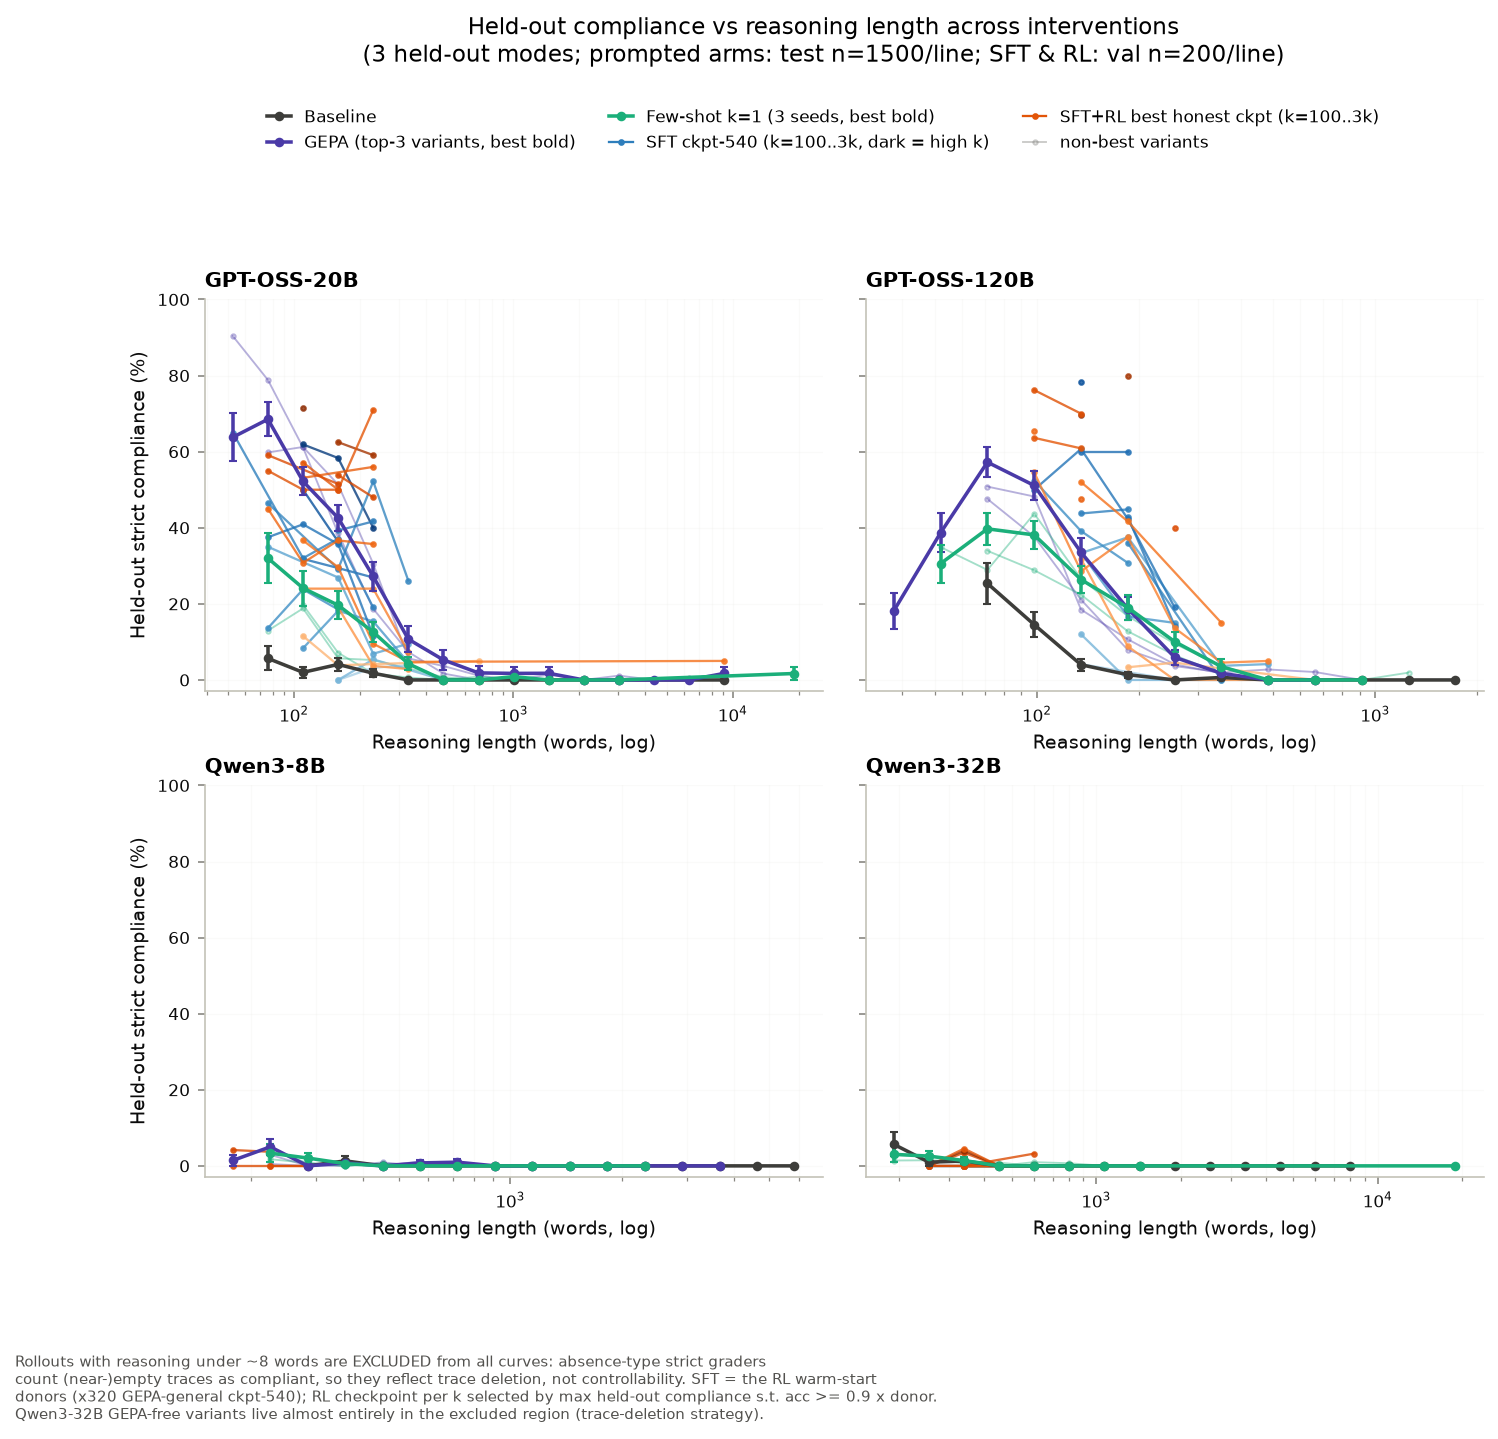

In [3]:
# Bucketing (gepa/plotting.ipynb convention, but PER-MODEL log-spaced grids:
# a single global grid gets stretched by qwen 20k-word outliers and leaves each
# line only ~3 occupied bins). Min bin size scales with line n (1500 -> 50, 200 -> 20).
def model_bins(mdf):
    w = mdf.loc[mdf["reasoning_words"] >= EMPTYISH, "reasoning_words"]
    return np.geomspace(max(w.quantile(0.002), EMPTYISH), w.quantile(0.998) * 1.001, 22)


def binned(sub, min_n, bins):
    sub = sub[sub["reasoning_words"] >= EMPTYISH]  # exclude near-empty traces (grader artifact)
    idx = np.digitize(sub["reasoning_words"], bins) - 1
    out = []
    for b in range(len(bins) - 1):
        m = idx == b
        n = int(m.sum())
        if n < min_n:
            continue
        p = sub.loc[m, "compliance"].mean()
        out.append((np.sqrt(bins[b] * bins[b + 1]), p, np.sqrt(p * (1 - p) / n), n))
    return np.array(out).reshape(-1, 4)


FAMS = {
    "baseline": dict(color="#3d3d3a", label="Baseline"),
    "gepa": dict(color=PALETTE[6], label="GEPA (top-3 variants, best bold)"),      # violet
    "fewshot": dict(color=PALETTE[2], label="Few-shot k=1 (3 seeds, best bold)"),  # aqua
}
cmap_sft, cmap_rl = plt.cm.Blues, plt.cm.Oranges
knorm = plt.matplotlib.colors.LogNorm(vmin=100, vmax=3000)
EMPTYISH = 8  # words; below this, absence-mode strict graders count near-empty traces as compliant

fig, axes = plt.subplots(2, 2, figsize=(11, 7.6), sharey=True,
                         gridspec_kw={"hspace": 0.24, "wspace": 0.07})

for ax, (m, name) in zip(axes.flat, MODELS):
    mdf = df[df["model"] == m]
    bins = model_bins(mdf)
    for fam, st in FAMS.items():
        for var, sub in mdf[mdf["family"] == fam].groupby("variant"):
            pts = binned(sub, 50, bins)
            if not len(pts):
                continue
            cx, p, se, n = pts.T
            if sub["bold"].iloc[0]:
                ax.errorbar(cx, 100 * p, yerr=100 * se, color=st["color"], marker="o",
                            ms=3.6, lw=1.7, capsize=2, zorder=4)
            else:
                ax.plot(cx, 100 * p, color=st["color"], lw=0.9, alpha=0.4,
                        marker="o", ms=2.0, markerfacecolor="none", zorder=2)
    for fam, cmap, z in (("sft", cmap_sft, 3), ("rl", cmap_rl, 3)):
        for var, sub in mdf[mdf["family"] == fam].groupby("variant"):
            pts = binned(sub, 20, bins)
            if not len(pts):
                continue
            cx, p, se, n = pts.T
            ax.plot(cx, 100 * p, color=cmap(0.35 + 0.6 * knorm(sub["k"].iloc[0])),
                    lw=1.1, alpha=0.8, marker="o", ms=2.2, zorder=z)
    ax.set_xscale("log")
    ax.xaxis.set_minor_formatter(plt.matplotlib.ticker.NullFormatter())
    ax.set_title(name, fontsize=10)
    ax.grid(True, which="both", alpha=0.15)
    ax.set_ylim(-3, 100)

for ax in axes.flat:
    ax.set_xlabel("Reasoning length (words, log)")
for ax in axes[:, 0]:
    ax.set_ylabel("Held-out strict compliance (%)")

handles = [plt.Line2D([], [], color=st["color"], lw=1.7, marker="o", ms=3.6, label=st["label"])
           for st in FAMS.values()]
handles += [plt.Line2D([], [], color=cmap_sft(0.7), lw=1.1, marker="o", ms=2.2,
                       label="SFT ckpt-540 (k=100..3k, dark = high k)"),
            plt.Line2D([], [], color=cmap_rl(0.7), lw=1.1, marker="o", ms=2.2,
                       label="SFT+RL best honest ckpt (k=100..3k)"),
            plt.Line2D([], [], color="#7a7a76", lw=0.9, alpha=0.4, marker="o", ms=2.0,
                       markerfacecolor="none", label="non-best variants")]
fig.legend(handles=handles, ncols=3, loc="upper center", bbox_to_anchor=(0.5, 1.06), frameon=False)
fig.suptitle("Held-out compliance vs reasoning length across interventions\n"
             "(3 held-out modes; prompted arms: test n=1500/line; SFT & RL: val n=200/line)",
             y=1.13, fontsize=11)
fig.text(0.01, -0.045,
         "Rollouts with reasoning under ~8 words are EXCLUDED from all curves: absence-type strict graders\n"
         "count (near-)empty traces as compliant, so they reflect trace deletion, not controllability. SFT = the RL warm-start\n"
         "donors (x320 GEPA-general ckpt-540); RL checkpoint per k selected by max held-out compliance s.t. acc >= 0.9 x donor.\n"
         "Qwen3-32B GEPA-free variants live almost entirely in the excluded region (trace-deletion strategy).",
         fontsize=7, color="#52514e", va="top")

out = REPO / "rl/analysis/interventions_compliance_vs_length.png"
fig.savefig(out, bbox_inches="tight", dpi=180)
print(f"saved {out}")
plt.show()

# Held-out trajectories over RL, per run (sweep14)

One line per k (viridis, dark = low k), from each run's built-in held-out eval (3 held-out modes, 200q val,
every 10 iterations). Same data underlying the SFT/RL lines above: step 0 = the SFT donor.

saved /root/controllability-elicitation/rl/analysis/sweep14_heldout_compliance_trajectories.png


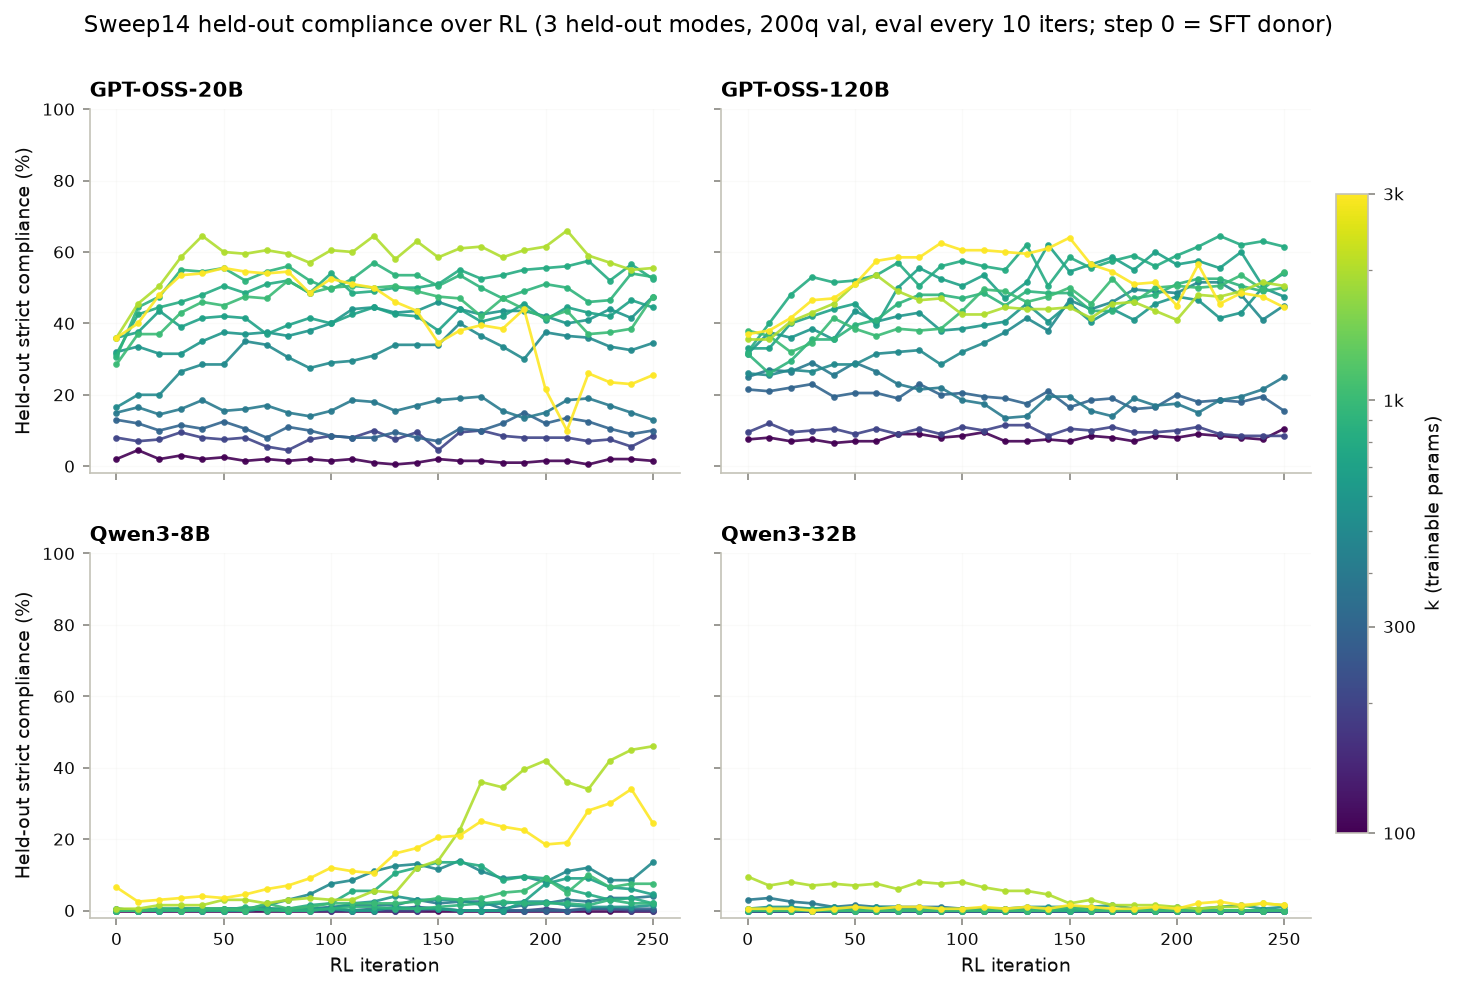

saved /root/controllability-elicitation/rl/analysis/sweep14_heldout_accuracy_trajectories.png


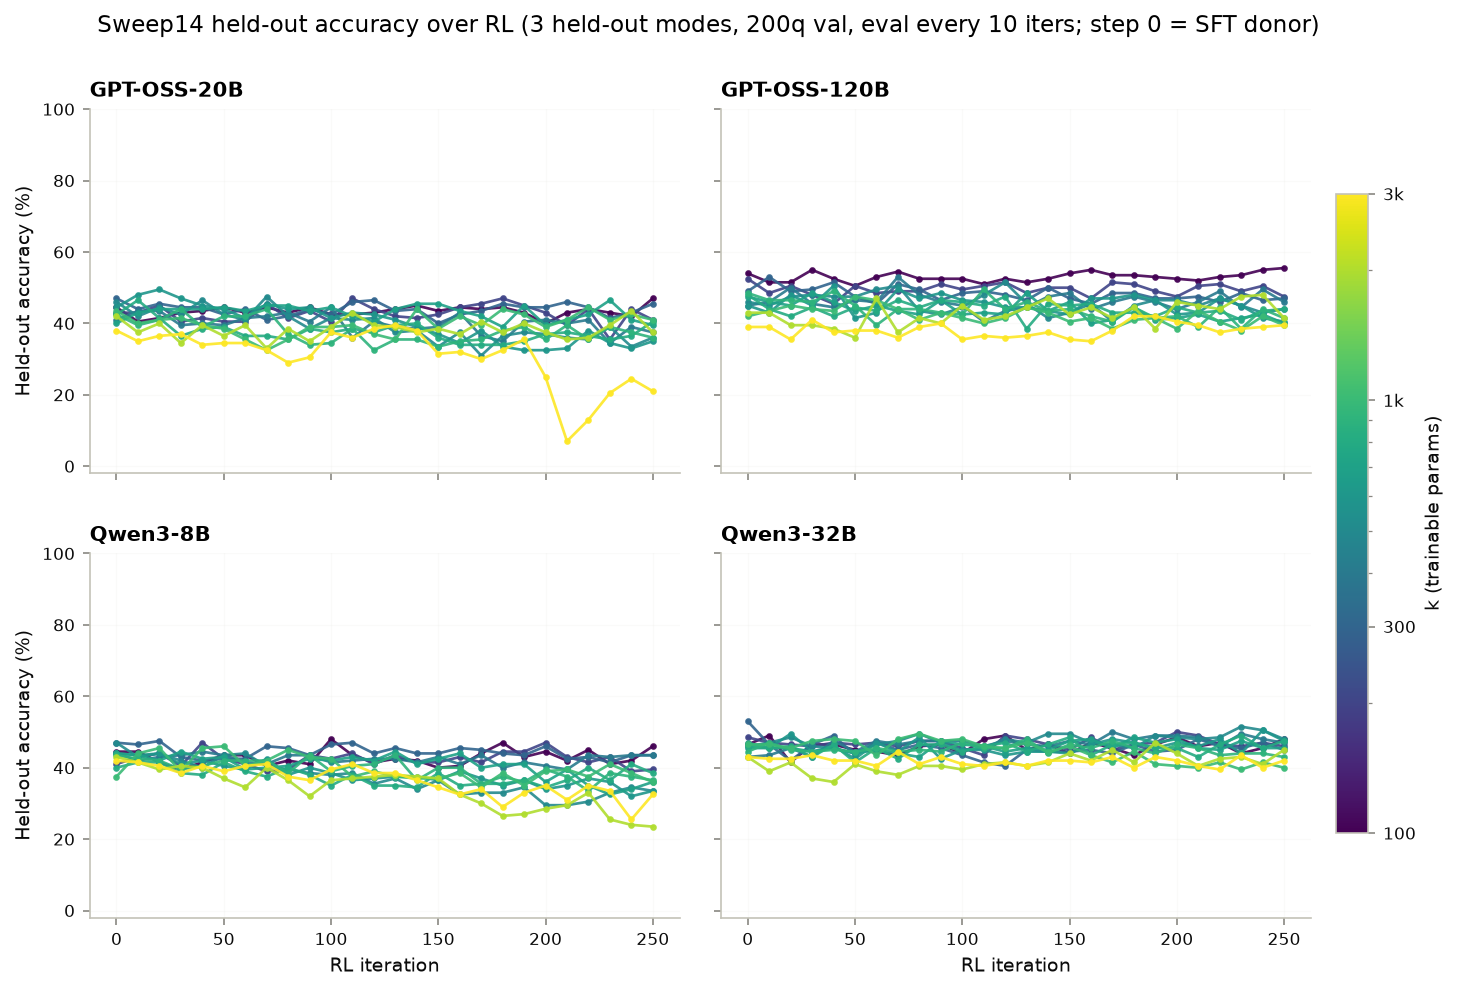

In [4]:
from matplotlib.cm import viridis
from matplotlib.colors import LogNorm
from matplotlib.cm import ScalarMappable

knorm_v = LogNorm(vmin=100, vmax=3000)


def traj(m, kl):
    p = REPO / f"rl/runs/sweep14_x320gepa_{m}/sweep14-x320gepa-{m}-{kl}/eval_summary.json"
    ev = json.loads(p.read_text())
    cks = sorted(ev if isinstance(ev, list) else ev.get("checkpoints", []), key=lambda c: c["step"])
    return ([c["step"] for c in cks], [c["compliance_rate"] for c in cks], [c["accuracy"] for c in cks])


for metric, idx, ylab, fname in [
        ("compliance", 1, "Held-out strict compliance (%)", "sweep14_heldout_compliance_trajectories.png"),
        ("accuracy", 2, "Held-out accuracy (%)", "sweep14_heldout_accuracy_trajectories.png")]:
    fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True, sharey=True,
                             gridspec_kw={"hspace": 0.22, "wspace": 0.07})
    for ax, (m, name) in zip(axes.flat, MODELS):
        for kl, kv in KS:
            t = traj(m, kl)
            ax.plot(t[0], [100 * v for v in t[idx]], color=viridis(knorm_v(kv)),
                    lw=1.3, marker="o", ms=2.2, alpha=0.9)
        ax.set_title(name, fontsize=10)
        ax.grid(True, alpha=0.15)
        ax.set_ylim(-2, 100)
    for ax in axes[1]:
        ax.set_xlabel("RL iteration")
    for ax in axes[:, 0]:
        ax.set_ylabel(ylab)
    sm = ScalarMappable(norm=knorm_v, cmap=viridis)
    cbar = fig.colorbar(sm, ax=axes, fraction=0.025, pad=0.02,
                        ticks=[100, 300, 1000, 3000])
    cbar.ax.set_yticklabels(["100", "300", "1k", "3k"])
    cbar.set_label("k (trainable params)")
    fig.suptitle(f"Sweep14 held-out {metric} over RL (3 held-out modes, 200q val, eval every 10 iters; "
                 "step 0 = SFT donor)", y=0.97, fontsize=11)
    out = REPO / f"rl/analysis/{fname}"
    fig.savefig(out, bbox_inches="tight", dpi=180)
    print(f"saved {out}")
    plt.show()

# RL gain by k (gpt-oss only)

Gain = held-out compliance at the FINAL checkpoint (it250) minus the SFT donor (it0), per k.

saved /root/controllability-elicitation/rl/analysis/sweep14_rl_gain_by_k.png


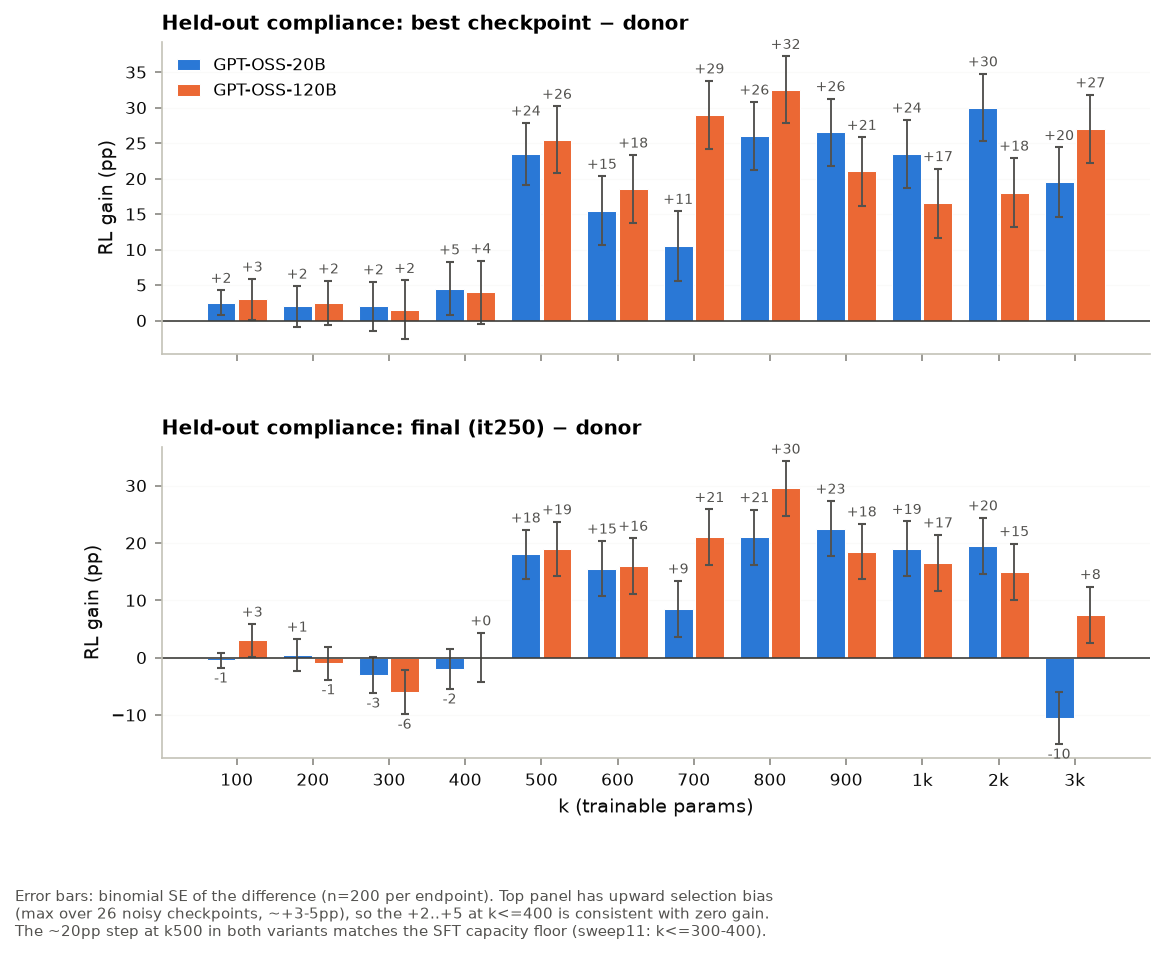

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(8.5, 6.2), sharex=True,
                         gridspec_kw={"hspace": 0.3})
xs = np.arange(len(KS))
width = 0.38
for ax, (label, pick) in zip(axes, [
        ("best checkpoint − donor", lambda c: max(c)),
        ("final (it250) − donor", lambda c: c[-1])]):
    for i, (m, name, color) in enumerate([("gptoss20b", "GPT-OSS-20B", PALETTE[0]),
                                          ("gptoss120b", "GPT-OSS-120B", PALETTE[1])]):
        gains, errs = [], []
        for kl, kv in KS:
            s, c_, a = traj(m, kl)
            p0, p1 = c_[0], pick(c_)
            gains.append(100 * (p1 - p0))
            errs.append(100 * np.sqrt(p0 * (1 - p0) / 200 + p1 * (1 - p1) / 200))
        bars = ax.bar(xs + (i - 0.5) * (width + 0.03), gains, width, yerr=errs, capsize=2,
                      color=color, edgecolor="white", linewidth=0.5, label=name,
                      error_kw=dict(lw=0.9, ecolor="#52514e"))
        ax.bar_label(bars, labels=[f"{g:+.0f}" for g in gains], fontsize=6.5,
                     color="#52514e", padding=2)
    ax.axhline(0, color="#3d3d3a", lw=0.8)
    ax.set_ylabel("RL gain (pp)")
    ax.set_title(f"Held-out compliance: {label}", fontsize=9.5)
    ax.grid(True, axis="y", alpha=0.15)
axes[0].legend(loc="upper left", fontsize=8)
axes[1].set_xticks(xs, [kl[1:] for kl, _ in KS])
axes[1].set_xlabel("k (trainable params)")
fig.text(0.01, -0.03,
         "Error bars: binomial SE of the difference (n=200 per endpoint). Top panel has upward selection bias\n"
         "(max over 26 noisy checkpoints, ~+3-5pp), so the +2..+5 at k<=400 is consistent with zero gain.\n"
         "The ~20pp step at k500 in both variants matches the SFT capacity floor (sweep11: k<=300-400).",
         fontsize=7, color="#52514e", va="top")
out = REPO / "rl/analysis/sweep14_rl_gain_by_k.png"
fig.savefig(out, bbox_inches="tight", dpi=180)
print(f"saved {out}")
plt.show()

# RL gain by k — IN-DISTRIBUTION (gpt-oss only)

Same layout as the held-out gain figure, but on the 7 training modes. No fixed in-dist eval exists for the RL
runs, so this uses the training rollouts (progress.jsonl: 256 rollouts/iter, temperature 1, random mode mix) —
endpoints are means over 5-iteration windows (n≈1280) to tame mode-mix noise, "best" is the max 5-iter rolling mean.

saved /root/controllability-elicitation/rl/analysis/sweep14_rl_gain_by_k_indist.png


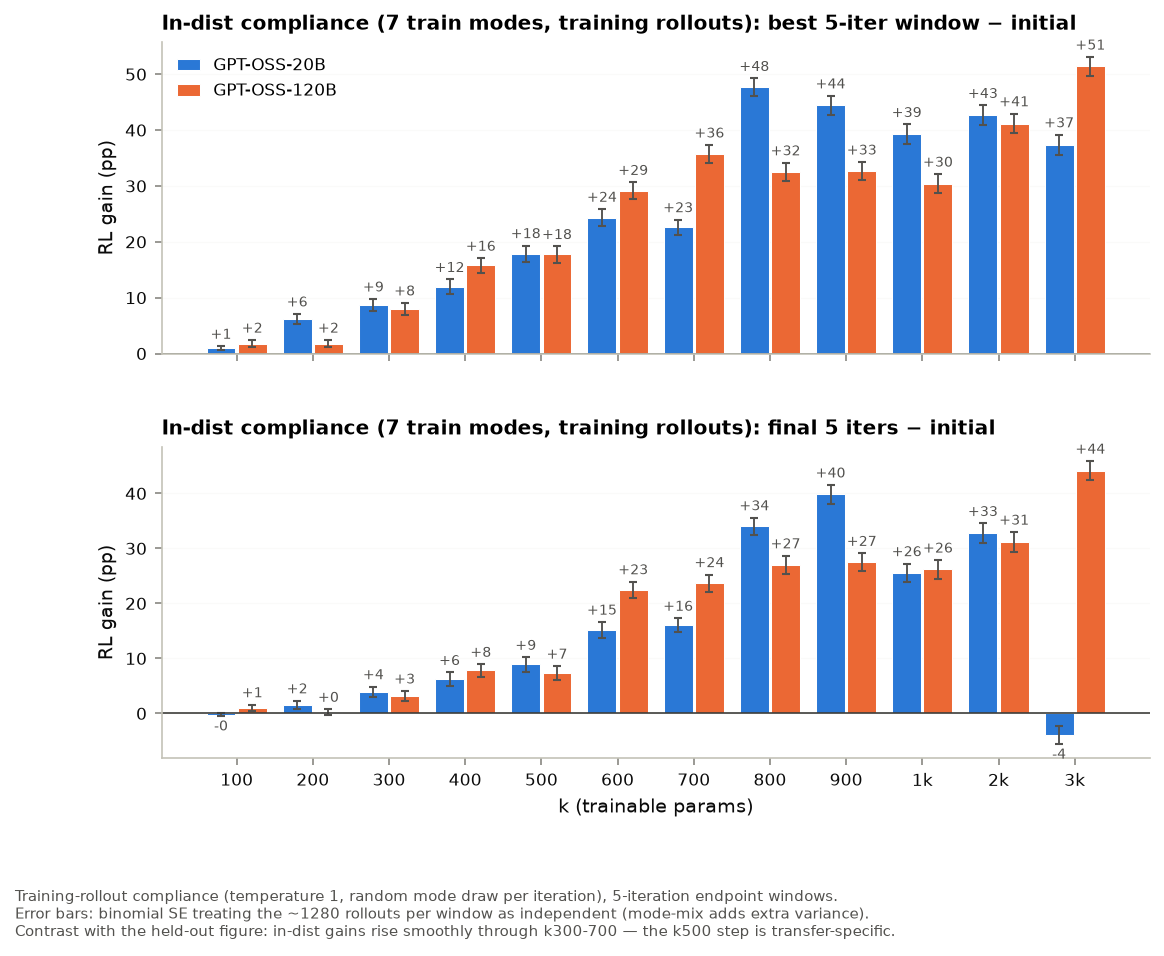

In [6]:
def indist(m, kl):
    rows = {}
    for line in open(REPO / f"rl/runs/sweep14_x320gepa_{m}/sweep14-x320gepa-{m}-{kl}/progress.jsonl"):
        d = json.loads(line)
        rows[d["iteration"]] = d["compliance_rate"]  # last-wins on resume replays
    c = [rows[i] for i in sorted(rows)]
    roll = [np.mean(c[i:i + 5]) for i in range(len(c) - 4)]
    return np.mean(c[:5]), max(roll), np.mean(c[-5:])


fig, axes = plt.subplots(2, 1, figsize=(8.5, 6.2), sharex=True,
                         gridspec_kw={"hspace": 0.3})
xs = np.arange(len(KS))
width = 0.38
NEFF = 5 * 256
for ax, idx, label in [(axes[0], 1, "best 5-iter window − initial"),
                       (axes[1], 2, "final 5 iters − initial")]:
    for i, (m, name, color) in enumerate([("gptoss20b", "GPT-OSS-20B", PALETTE[0]),
                                          ("gptoss120b", "GPT-OSS-120B", PALETTE[1])]):
        gains, errs = [], []
        for kl, kv in KS:
            v = indist(m, kl)
            p0, p1 = v[0], v[idx]
            gains.append(100 * (p1 - p0))
            errs.append(100 * np.sqrt(p0 * (1 - p0) / NEFF + p1 * (1 - p1) / NEFF))
        bars = ax.bar(xs + (i - 0.5) * (width + 0.03), gains, width, yerr=errs, capsize=2,
                      color=color, edgecolor="white", linewidth=0.5, label=name,
                      error_kw=dict(lw=0.9, ecolor="#52514e"))
        ax.bar_label(bars, labels=[f"{g:+.0f}" for g in gains], fontsize=6.5,
                     color="#52514e", padding=2)
    ax.axhline(0, color="#3d3d3a", lw=0.8)
    ax.set_ylabel("RL gain (pp)")
    ax.set_title(f"In-dist compliance (7 train modes, training rollouts): {label}", fontsize=9.5)
    ax.grid(True, axis="y", alpha=0.15)
axes[0].legend(loc="upper left", fontsize=8)
axes[1].set_xticks(xs, [kl[1:] for kl, _ in KS])
axes[1].set_xlabel("k (trainable params)")
fig.text(0.01, -0.03,
         "Training-rollout compliance (temperature 1, random mode draw per iteration), 5-iteration endpoint windows.\n"
         "Error bars: binomial SE treating the ~1280 rollouts per window as independent (mode-mix adds extra variance).\n"
         "Contrast with the held-out figure: in-dist gains rise smoothly through k300-700 — the k500 step is transfer-specific.",
         fontsize=7, color="#52514e", va="top")
out = REPO / "rl/analysis/sweep14_rl_gain_by_k_indist.png"
fig.savefig(out, bbox_inches="tight", dpi=180)
print(f"saved {out}")
plt.show()

# In-dist trajectories over RL, per run (sweep14)

Same layout as the held-out trajectories, but on the 7 training modes, from the training rollouts
(progress.jsonl: 256 rollouts/iter, temperature 1, random mode draw per iteration). Lines are 5-iteration
rolling means to tame the per-iteration mode-mix noise.

saved /root/controllability-elicitation/rl/analysis/sweep14_indist_compliance_trajectories.png


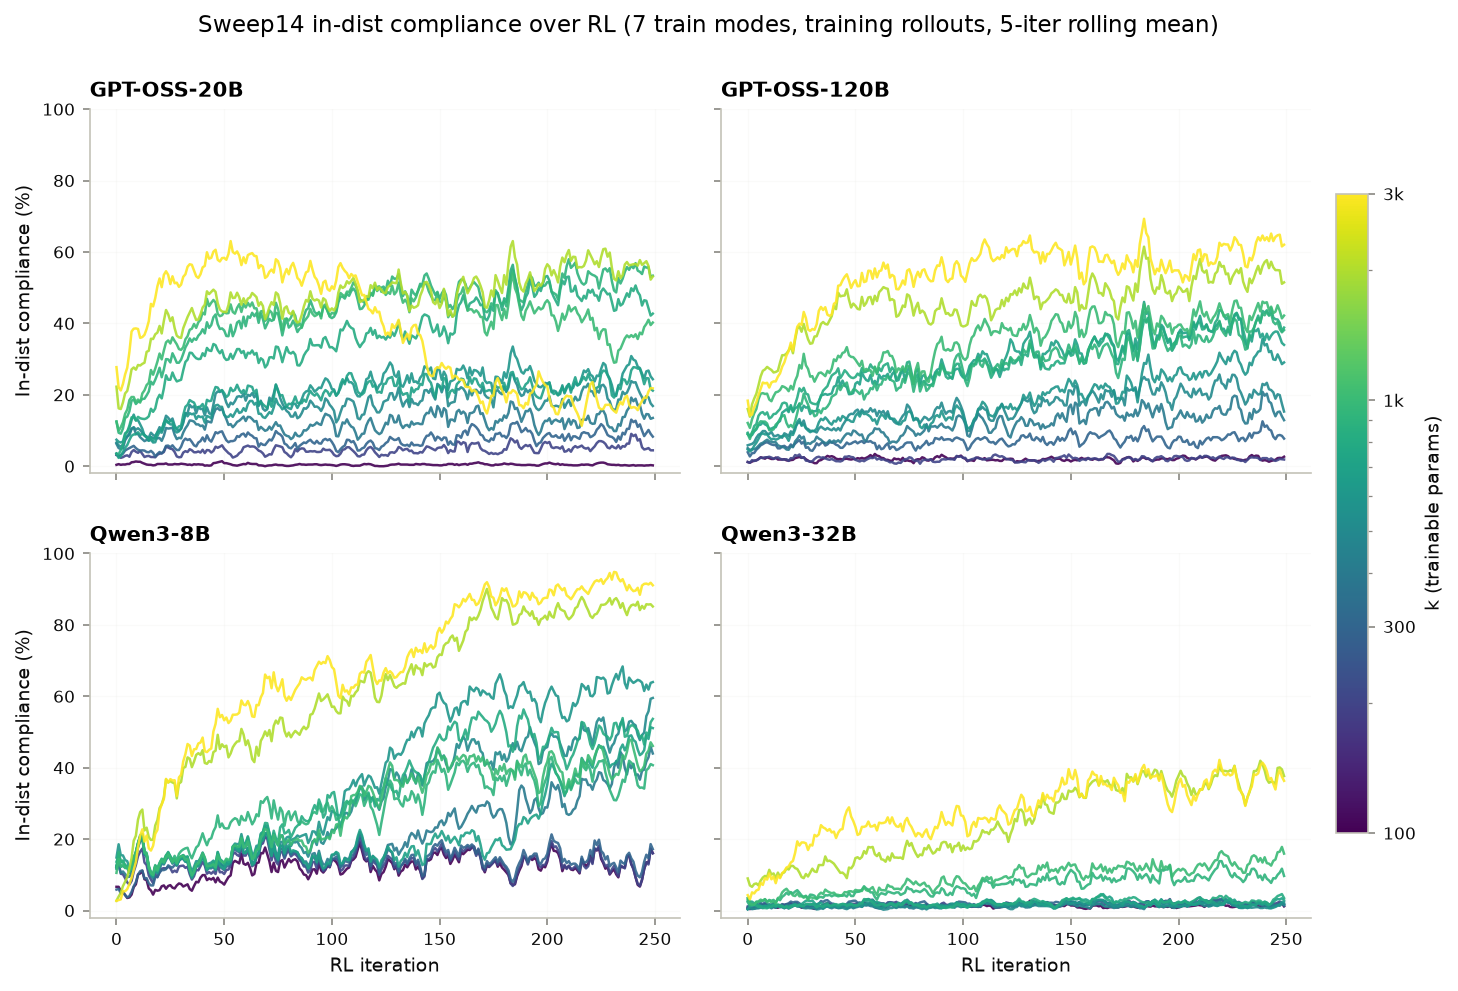

saved /root/controllability-elicitation/rl/analysis/sweep14_indist_accuracy_trajectories.png


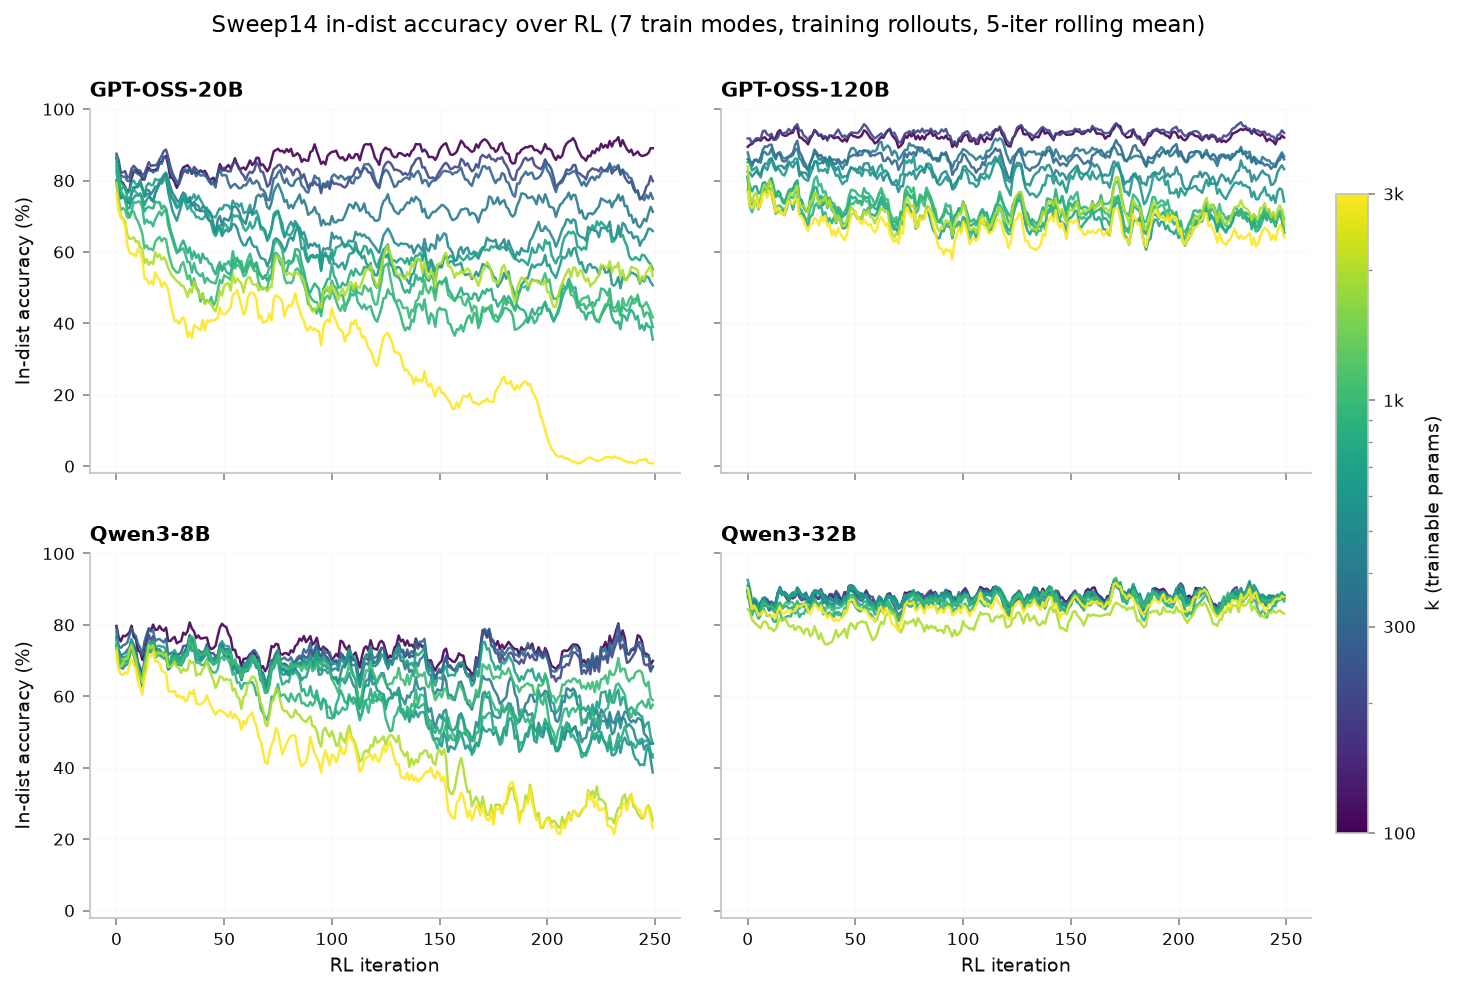

In [7]:
def indist_traj(m, kl, key):
    rows = {}
    for line in open(REPO / f"rl/runs/sweep14_x320gepa_{m}/sweep14-x320gepa-{m}-{kl}/progress.jsonl"):
        d = json.loads(line)
        rows[d["iteration"]] = d[key]  # last-wins on resume replays
    its = sorted(rows)
    v = [rows[i] for i in its]
    W = 5
    sm = [np.mean(v[max(0, i - W + 1):i + 1]) for i in range(len(v))]
    return its, sm


for key, ylab, fname in [
        ("compliance_rate", "In-dist compliance (%)", "sweep14_indist_compliance_trajectories.png"),
        ("accuracy", "In-dist accuracy (%)", "sweep14_indist_accuracy_trajectories.png")]:
    fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True, sharey=True,
                             gridspec_kw={"hspace": 0.22, "wspace": 0.07})
    for ax, (m, name) in zip(axes.flat, MODELS):
        for kl, kv in KS:
            its, sm = indist_traj(m, kl, key)
            ax.plot(its, [100 * v for v in sm], color=viridis(knorm_v(kv)), lw=1.2, alpha=0.9)
        ax.set_title(name, fontsize=10)
        ax.grid(True, alpha=0.15)
        ax.set_ylim(-2, 100)
    for ax in axes[1]:
        ax.set_xlabel("RL iteration")
    for ax in axes[:, 0]:
        ax.set_ylabel(ylab)
    sm_ = ScalarMappable(norm=knorm_v, cmap=viridis)
    cbar = fig.colorbar(sm_, ax=axes, fraction=0.025, pad=0.02, ticks=[100, 300, 1000, 3000])
    cbar.ax.set_yticklabels(["100", "300", "1k", "3k"])
    cbar.set_label("k (trainable params)")
    fig.suptitle(f"Sweep14 in-dist {key.replace('_rate','')} over RL "
                 "(7 train modes, training rollouts, 5-iter rolling mean)", y=0.97, fontsize=11)
    out = REPO / f"rl/analysis/{fname}"
    fig.savefig(out, bbox_inches="tight", dpi=180)
    print(f"saved {out}")
    plt.show()